:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_05_place_cells.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings
import jax

jax.config.update("jax_enable_x64", True)

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

# Fit place cell

The data for this example are from [Grosmark, Andres D., and György Buzsáki. "Diversity in neural firing dynamics supports both rigid and learned hippocampal sequences." Science 351.6280 (2016): 1440-1443](https://www.science.org/doi/full/10.1126/science.aad1935).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
from scipy.ndimage import gaussian_filter

import nemos as nmo

# some helper plotting functions
from nemos import _documentation_utils as doc_plots

# configure plots some
plt.style.use(nmo.styles.plot_style)

# shut down jax to numpy conversion warning
nap.nap_config.suppress_conversion_warnings = True

(place-cells-data)=
## Data Streaming

Here we load the data from OSF. The data is a NWB file.

In [3]:
path = nmo.fetch.fetch_data("Achilles_10252013.nwb")

## Pynapple
We are going to open the NWB file with pynapple

In [4]:
data = nap.load_file(path)

data

Achilles_10252013
┍━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys        │ Type        │
┝━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units       │ TsGroup     │
│ trials      │ IntervalSet │
│ theta_phase │ Tsd         │
│ position    │ Tsd         │
┕━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

Let's extract the spike times, the position and the theta phase.

In [5]:
spikes = data["units"]
position = data["position"]
theta = data["theta_phase"]

The NWB file also contains the time at which the animal was traversing the linear track. We can use it to restrict the position and assign it as the `time_support` of position.

In [6]:
position = position.restrict(data["trials"])

The recording contains both inhibitory and excitatory neurons. Here we will focus of the excitatory cells. Neurons have already been labelled before.

In [7]:
spikes = spikes.getby_category("cell_type")["pE"]

We can discard the low firing neurons as well.

In [8]:
spikes = spikes.getby_threshold("rate", 0.3)

## Place fields
Let's plot some data. We start by making place fields i.e firing rate as a function of position.

In [9]:
pf = nap.compute_tuning_curves(spikes, position, 50, epochs=position.time_support, feature_names=["pos"])

Let's do a quick sort of the place fields for display

In [10]:
order = np.argsort(pf.idxmax(dim="pos"))

Here each row is one neuron

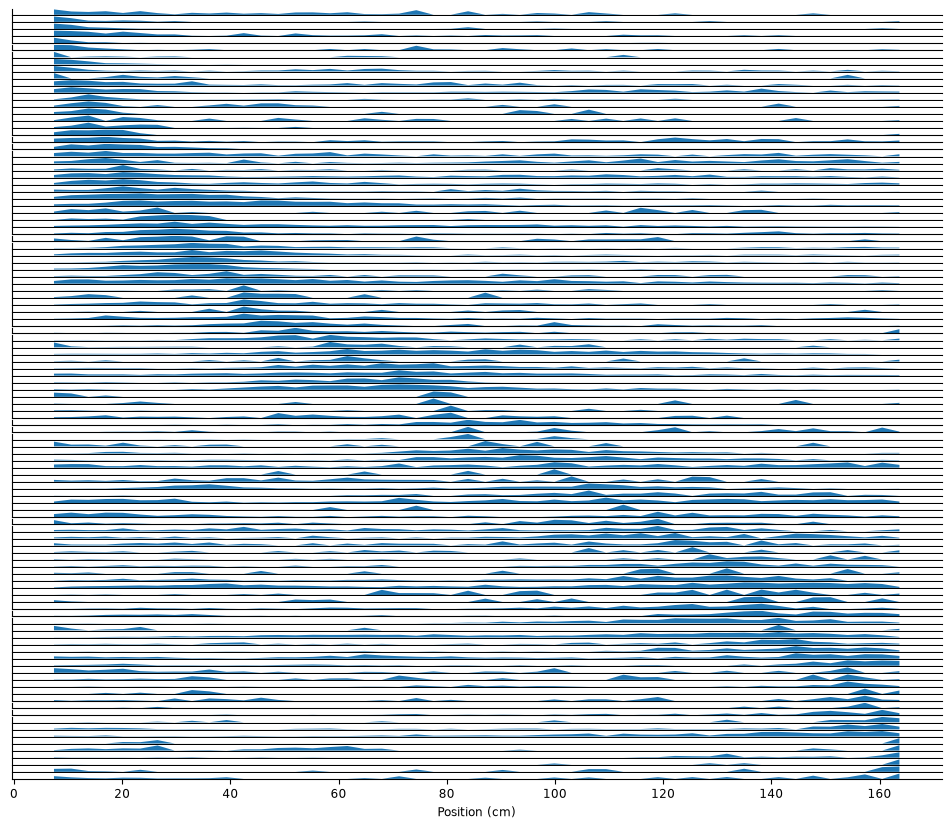

In [11]:
fig = plt.figure(figsize=(12, 10))
gs = plt.GridSpec(len(spikes), 1)
for i, n in enumerate(order):
    plt.subplot(gs[i, 0])
    plt.fill_between(pf.pos, np.zeros(pf.shape[1]), pf[n])
    if i < len(spikes) - 1:
        plt.xticks([])
    else:
        plt.xlabel("Position (cm)")
    plt.yticks([])

In [12]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/tutorials"
# if local store in assets
else:
   path = Path("../_build/html/_static/thumbnails/tutorials")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_05_place_cells.svg")

## Phase precession

In addition to place modulation, place cells are also modulated by the theta oscillation. The phase at which neurons fire is dependant of the position. This phenomen is called "phase precession" (see [J. O’Keefe, M. L. Recce, "Phase relationship between hippocampal place units and the EEG theta rhythm." Hippocampus 3, 317–330 (1993).](https://doi.org/10.1002/hipo.450030307)).

Let's compute the response of the neuron as a function of both theta and position. The phase of theta has already been computed but we have to bring it to the same dimension as the position feature. While the position has been sampled at 40Hz, the theta phase has been computed at 1250Hz.
Later on during the analysis, we will use a bin size of 5 ms for counting the spikes. Since this corresponds to an intermediate frequency between 40 and 1250 Hz, we will bring all the features to 200Hz already.

In [13]:
bin_size = 0.005

theta = theta.bin_average(bin_size, position.time_support)
theta = (theta + 2 * np.pi) % (2 * np.pi)

data = nap.TsdFrame(
    t=theta.t,
    d=np.vstack(
        (position.interpolate(theta, ep=position.time_support).values, theta.values)
    ).T,
    time_support=position.time_support,
    columns=["position", "theta"],
)

print(data)

Time (s)              position     theta
------------------  ----------  --------
18193.601302655        6.3501   0.720726
18193.606302655        6.42559  0.962317
18193.611302654997     6.50107  1.20539
18193.616302655        6.57655  1.4315
18193.621302655        6.65203  1.65962
18193.626302655        6.74664  1.90942
18193.631302654998     6.87245  2.16228
...
20123.365182821      164.962    4.80564
20123.370182821      165.012    5.08064
20123.375182820997   165.062    5.38295
20123.380182820998   165.113    5.68912
20123.385182821      165.163    5.97462
20123.390182821      165.213    6.26204
20123.395182820997   165.264    0.267264
dtype: float64, shape: (38458, 2)


`data` is a [`TsdFrame`](https://pynapple.org/generated/pynapple.TsdTensor.html) that contains the position and phase. Before calling [`compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves) from pynapple to observe the theta phase precession, we will restrict the analysis to the place field of one neuron.

There are a lot of neurons but for this analysis, we will focus on one neuron only.

Text(0, 0.5, 'Firing rate (Hz)')

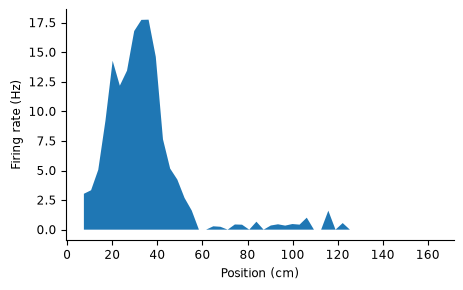

In [14]:
neuron = 175

plt.figure(figsize=(5,3))
plt.fill_between(pf.sel(unit=neuron).pos, np.zeros(pf.shape[1]), pf.sel(unit=neuron))
plt.xlabel("Position (cm)")
plt.ylabel("Firing rate (Hz)")

This neurons place field is between 0 and 60 cm within the linear track. Here we will use the `threshold` function of pynapple to quickly compute the epochs for which the animal is within the place field :

In [15]:
within_ep = position.threshold(60.0, method="below").time_support

`within_ep` is an [`IntervalSet`](https://pynapple.org/generated/pynapple.IntervalSet.html). We can now give it to [`compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves) along with the spiking activity and the position-phase features.

In [16]:
tc_pos_theta = nap.compute_tuning_curves(spikes, data, 20, epochs=within_ep)

To show the theta phase precession, we can also display the spike as a function of both position and theta. In this case, we use the function `value_from` from pynapple.

In [17]:
theta_pos_spikes = spikes[neuron].value_from(data, ep = within_ep)

Now we can plot everything together :

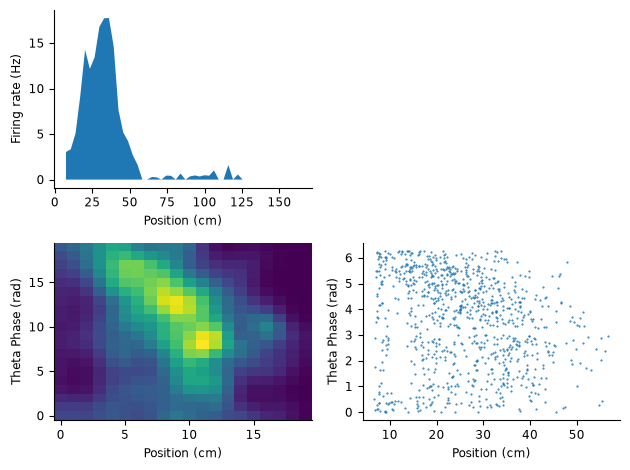

In [18]:
plt.figure()
gs = plt.GridSpec(2, 2)
plt.subplot(gs[0, 0])
plt.fill_between(pf.sel(unit=neuron).pos, np.zeros(pf.shape[1]), pf.sel(unit=neuron))
plt.xlabel("Position (cm)")
plt.ylabel("Firing rate (Hz)")

plt.subplot(gs[1, 0])
tc_pos_theta_filt = gaussian_filter(tc_pos_theta.sel(unit=neuron).T, 1)
plt.imshow(tc_pos_theta_filt, aspect="auto", origin="lower")
plt.xlabel("Position (cm)")
plt.ylabel("Theta Phase (rad)")

plt.subplot(gs[1, 1])
plt.plot(theta_pos_spikes["position"], theta_pos_spikes["theta"], "o", markersize=0.5)
plt.xlabel("Position (cm)")
plt.ylabel("Theta Phase (rad)")

plt.tight_layout()

## Speed modulation
The speed at which the animal traverse the field is not homogeneous. Does it influence the firing rate of hippocampal neurons? We can compute tuning curves for speed as well as average speed across the maze.
In the next block, we compute the speed of the animal for each epoch (i.e. crossing of the linear track) by doing the difference of two consecutive position multiplied by the sampling rate of the position.

In [19]:
speed = []
for s, e in data.time_support.values: # Time support contains the epochs
    pos_ep = data["position"].get(s, e)
    speed_ep = np.abs(np.diff(pos_ep)) # Absolute difference of two consecutive points
    speed_ep = np.pad(speed_ep, [0, 1], mode="edge") # Adding one point at the end to match the size of the position array
    speed_ep = speed_ep * data.rate # Converting to cm/s
    speed.append(speed_ep)

speed = nap.Tsd(t=data.t, d=np.hstack(speed), time_support=data.time_support)

Now that we have the speed of the animal, we can compute the tuning curves for speed modulation. Here we call pynapple [`compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves):

In [20]:
tc_speed = nap.compute_tuning_curves(spikes, speed, 20, feature_names=["speed"])

To assess the variabilty in speed when the animal is travering the linear track, we can compute the average speed and estimate the standard deviation. Here we use numpy only and put the results in a pandas [`DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html):

In [21]:
bins = np.linspace(np.min(data["position"]), np.max(data["position"]), 20)

idx = np.digitize(data["position"].values, bins)

mean_speed = np.array([np.mean(speed[idx==i]) for i in np.unique(idx)])
std_speed = np.array([np.std(speed[idx==i]) for i in np.unique(idx)])

Here we plot the tuning curve of one neuron for speed as well as the average speed as a function of the animal position

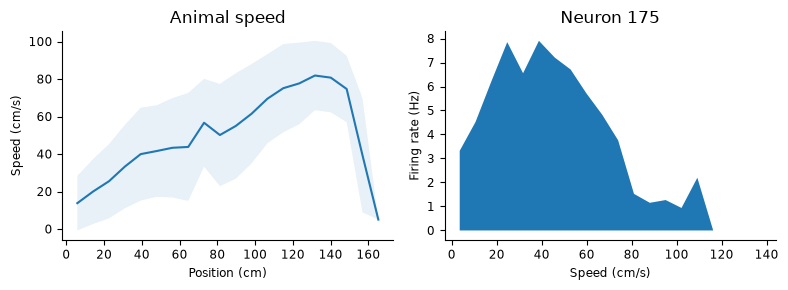

In [22]:
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.plot(bins, mean_speed)
plt.fill_between(
    bins,
    mean_speed - std_speed,
    mean_speed + std_speed,
    alpha=0.1,
)
plt.xlabel("Position (cm)")
plt.ylabel("Speed (cm/s)")
plt.title("Animal speed")
plt.subplot(122)
plt.fill_between(
    tc_speed.speed, np.zeros(tc_speed.shape[1]), tc_speed.sel(unit=neuron)
)
plt.xlabel("Speed (cm/s)")
plt.ylabel("Firing rate (Hz)")
plt.title("Neuron {}".format(neuron))
plt.tight_layout()

This neurons show a strong modulation of firing rate as a function of speed but we can also notice that the animal, on average, accelerates when travering the field. Is the speed tuning we observe a true modulation or spurious correlation caused by traversing the place field at different speed and for different theta phase? We can use NeMoS to model the activity and give the position, the phase and the speed as input variable.

We will use speed, phase and position to model the activity of the neuron.
All the feature have already been brought to the same dimension thanks to `pynapple`.

In [23]:
position = data["position"]
theta = data["theta"]
count = spikes[neuron].count(bin_size, data.time_support)

print(position.shape)
print(theta.shape)
print(speed.shape)
print(count.shape)

(38458,)
(38458,)
(38458,)
(38458,)


(basis_eval_place_cells)=
## Basis evaluation

For each feature, we will use a different set of basis :

  -   position : [`MSplineEval`](nemos.basis.MSplineEval)
  -   theta phase : [`CyclicBSplineEval`](nemos.basis.CyclicBSplineEval)
  -   speed : [`MSplineEval`](nemos.basis.MSplineEval)

In [24]:
position_basis = nmo.basis.MSplineEval(n_basis_funcs=10, label="position")
phase_basis = nmo.basis.CyclicBSplineEval(n_basis_funcs=12, label="theta_phase")
speed_basis = nmo.basis.MSplineEval(n_basis_funcs=15, label="speed")

In addition, we will consider position and phase to be a joint variable. In NeMoS, we can combine basis by multiplying them and adding them. In this case the final basis object for our model can be made in one line :

In [25]:
basis = position_basis * phase_basis + speed_basis
basis.label = "full_design"
basis

,label,'full_design'
,position__bounds,None
,position__fill_value,nan
,position__label,'position'
,position__n_basis_funcs,10
,position__order,4
,position,"'position': M...s=10, order=4)"
,theta_phase__bounds,None
,theta_phase__fill_value,nan
,theta_phase__label,'theta_phase'
,theta_phase__n_basis_funcs,12


The object basis only tell us how each basis covers the feature space. For each timestep, we need to _evaluate_ what are the features value. For that we can call NeMoS basis:

In [26]:
X = basis.compute_features(position, theta, speed)

`X` is our design matrix. For each timestamps, it contains the information about the current position,
speed and theta phase of the experiment. Notice how passing a pynapple object to the basis
also returns a `pynapple` object.

In [27]:
print(X)

Time (s)              0            1            2           3           4  ...
------------------  ---  -----------  -----------  ----------  ----------  -----
18193.601302655       0  0.00660401   0.0901329    0.0651957   0.00145198  ...
18193.606302655       0  0.000115029  0.0418531    0.103908    0.0158506   ...
18193.611302654997    0  0            0.00907136   0.0943215   0.055952    ...
18193.616302655       0  0            0.000497627  0.0516063   0.0959025   ...
18193.621302655       0  0            0            0.0149685   0.10042     ...
18193.626302655       0  0            0            0.00113818  0.0593979   ...
18193.631302654998    0  0            0            0           0.0167209   ...
...                                                                        ...
20123.365182821       0  0            0            0           0           ...
20123.370182821       0  0            0            0           0           ...
20123.375182820997    0  0            0           

## Model learning

We can now use the Poisson GLM from NeMoS to learn the model.

In [28]:
glm = nmo.glm.GLM()

glm.fit(X, count)

/home/jenkins/agent/workspace/CCN_nemos_PR-620/venv/lib/python3.12/site-packages/nemos/glm/glm.py:1122: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f29d0e70d60>
,regularizer,UnRegularized()
,fix_params,"(None, ...)"
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](135,)",Array([ 11.50...dtype=float64)


## Prediction

Let's check first if our model can accurately predict the different tuning curves we displayed above. We can use the [`predict`](nemos.glm.GLM.predict) function of NeMoS and then compute new tuning curves

In [29]:
predicted_rate = glm.predict(X) / bin_size

glm_pf = nap.compute_tuning_curves(predicted_rate[:, np.newaxis], position, 50, feature_names=["pos"])
glm_pos_theta = nap.compute_tuning_curves(
    predicted_rate[:, np.newaxis], data, 30, epochs=within_ep
)
glm_speed = nap.compute_tuning_curves(predicted_rate[:, np.newaxis], speed, 30, feature_names=["speed"])

Let's display both tuning curves together.

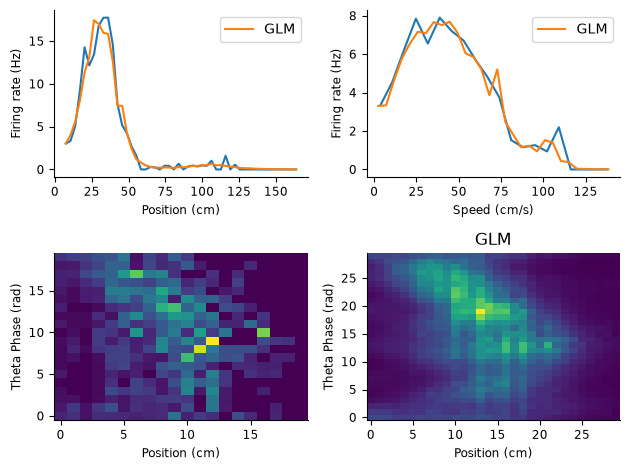

In [30]:
fig = doc_plots.plot_position_phase_speed_tuning(
    pf.sel(unit=neuron),
    glm_pf[0],
    tc_speed.sel(unit=neuron),
    glm_speed[0],
    tc_pos_theta.sel(unit=neuron),
    glm_pos_theta[0],
    )

## Model selection

While this model captures nicely the features-rate relationship, it is not necessarily the simplest model. Let's construct several models and evaluate their score to determine the best model.

:::{note}

To shorten this notebook, only a few combinations are tested. Feel free to expand this list.
:::

In [31]:
models = {
    "position": position_basis,
    "position + speed": position_basis + speed_basis,
    "position * phase": position_basis * phase_basis,
    "position * phase + speed": position_basis * phase_basis + speed_basis,
}
features = {
    "position": (position,),
    "position + speed": (position, speed),
    "position * phase": (position, theta),
    "position * phase + speed": (position, theta, speed),
}

In a loop, we can (1) evaluate the basis, (2), fit the model, (3) compute the score and (4) predict the firing rate. For evaluating the score, we can define a train set of intervals and a test set of intervals.

In [32]:
train_iset = position.time_support[::2] # Taking every other epoch
test_iset = position.time_support[1::2]

Let's train all the models.

In [33]:
scores = {}
predicted_rates = {}

for m in models:
    print("1. Evaluating basis : ", m)
    X = models[m].compute_features(*features[m])

    print("2. Fitting model : ", m)
    glm.fit(
        X.restrict(train_iset),
        count.restrict(train_iset),
    )

    print("3. Scoring model : ", m)
    scores[m] = glm.score(
        X.restrict(test_iset),
        count.restrict(test_iset),
        score_type="pseudo-r2-McFadden",
    )

    print("4. Predicting rate")
    predicted_rates[m] = glm.predict(X.restrict(test_iset)) / bin_size


scores = pd.Series(scores)
scores = scores.sort_values()

1. Evaluating basis :  position
2. Fitting model :  position


/home/jenkins/agent/workspace/CCN_nemos_PR-620/venv/lib/python3.12/site-packages/nemos/glm/glm.py:1122: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


3. Scoring model :  position


4. Predicting rate
1. Evaluating basis :  position + speed
2. Fitting model :  position + speed


3. Scoring model :  position + speed


4. Predicting rate
1. Evaluating basis :  position * phase
2. Fitting model :  position * phase


3. Scoring model :  position * phase


4. Predicting rate
1. Evaluating basis :  position * phase + speed
2. Fitting model :  position * phase + speed


3. Scoring model :  position * phase + speed


4. Predicting rate


Let's compute scores for each models.

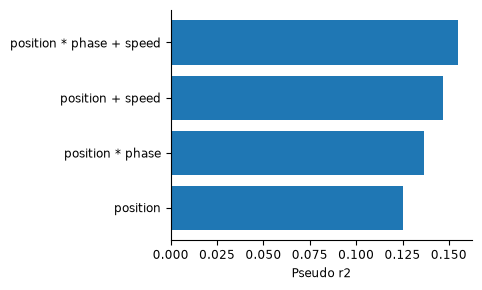

In [34]:
plt.figure(figsize=(5, 3))
plt.barh(np.arange(len(scores)), scores)
plt.yticks(np.arange(len(scores)), scores.index)
plt.xlabel("Pseudo r2")
plt.tight_layout()

Some models are doing better than others.

:::{warning}
A proper model comparison should be done by scoring models repetitively on various train and test set. Here we are only doing partial models comparison for the sake of conciseness.
:::

Alternatively, we can plot some tuning curves to compare each models visually.

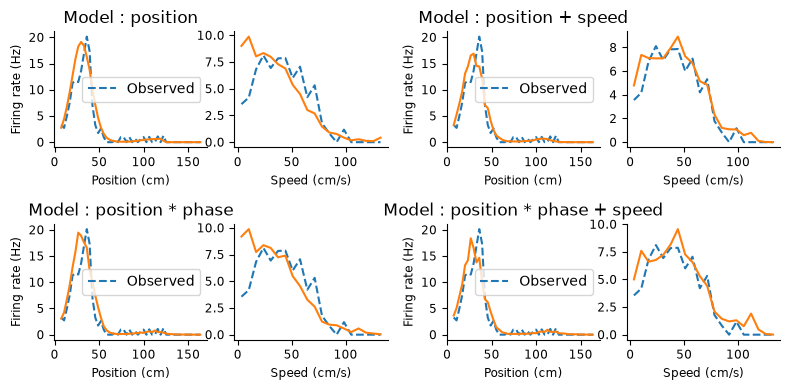

In [35]:
tuning_curves = {}

for m in models:
    tuning_curves[m] = {
        "position": nap.compute_tuning_curves(
            predicted_rates[m], position, 50, epochs=test_iset, feature_names=["pos"]
        ),
        "speed": nap.compute_tuning_curves(
            predicted_rates[m], speed, 20, epochs=test_iset, feature_names=["speed"]
        ),
    }

# recompute tuning from spikes restricting to the test-set
pf = nap.compute_tuning_curves(spikes, position, 50, epochs=test_iset, feature_names=["pos"])
tc_speed = nap.compute_tuning_curves(spikes, speed, 20, epochs=test_iset, feature_names=["speed"])


fig = plt.figure(figsize=(8, 4))
outer_grid = fig.add_gridspec(2, 2)
for i, m in enumerate(models):
    doc_plots.plot_position_speed_tuning(
        outer_grid[i // 2, i % 2],
        tuning_curves[m],
        pf.sel(unit=neuron),
        tc_speed.sel(unit=neuron),
        m)

plt.tight_layout()
plt.show()

## Conclusion

Various combinations of features can lead to different results. Feel free to explore more. To go beyond this notebook, you can check the following references :

  - [Hardcastle, Kiah, et al. "A multiplexed, heterogeneous, and adaptive code for navigation in medial entorhinal cortex." Neuron 94.2 (2017): 375-387](https://www.cell.com/neuron/pdf/S0896-6273(17)30237-4.pdf)

  - [McClain, Kathryn, et al. "Position–theta-phase model of hippocampal place cell activity applied to quantification of running speed modulation of firing rate." Proceedings of the National Academy of Sciences 116.52 (2019): 27035-27042](https://www.pnas.org/doi/abs/10.1073/pnas.1912792116)

  - [Peyrache, Adrien, Natalie Schieferstein, and Gyorgy Buzsáki. "Transformation of the head-direction signal into a spatial code." Nature communications 8.1 (2017): 1752.](https://www.nature.com/articles/s41467-017-01908-3)